# 08 — CNC spindle simulator (machine M-003)

This notebook is the M-003 counterpart of [`01_simulator_dev.ipynb`](01_simulator_dev.ipynb).
Where M-001 / M-002 are **synthetic FSM-physics** machines, **M-003 is
derived from real customer telemetry**: a CNC machining centre cutting engine
cylinder heads, sampled on the spindle (`mandrino`).

The pipeline is:

1. **Reorganise** the raw export (long / EAV, one row per signal sample) into a
   tidy wide table.
2. **Characterise** the real traffic pattern (duty cycle, cycle length, idle
   gaps, per-phase signal statistics).
3. **Build the empirical profile** → [`data/cnc_profile_M-003.json`](../data/cnc_profile_M-003.json).
4. **Replay** it through `simulator-local/cnc_engine.py` and confirm the
   synthetic stream matches the real one.

> The raw parquet lives under `_data_local/` (git-ignored — it is customer
> data). Only the **aggregate, de-identified** profile JSON is committed.
> Cells degrade gracefully when the raw data is absent.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except Exception:
    HAVE_MPL = False

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = REPO / "_data_local" / "parquet_files_raw"
WIDE_PARQUET = REPO / "_data_local" / "cnc_real_wide.parquet"
PROFILE_JSON = REPO / "data" / "cnc_profile_M-003.json"
sys.path.insert(0, str(REPO / "simulator-local"))
print("repo      :", REPO)
print("raw data  :", RAW_DIR, "(exists:", RAW_DIR.exists(), ")")
print("profile   :", PROFILE_JSON, "(exists:", PROFILE_JSON.exists(), ")")

repo      : C:\Users\faustopalma\OneDrive - Microsoft\Documents\Customers\Other\Iveco\anomalydetection
raw data  : C:\Users\faustopalma\OneDrive - Microsoft\Documents\Customers\Other\Iveco\anomalydetection\_data_local\parquet_files_raw (exists: True )
profile   : C:\Users\faustopalma\OneDrive - Microsoft\Documents\Customers\Other\Iveco\anomalydetection\data\cnc_profile_M-003.json (exists: True )


## 1 — The raw export (long / EAV)

Each row is a single signal sample. Columns: `ts`, `work_date`,
`signal_name`, `value`, `measure_id`, `export_timestamp`. There is **no unit
column** — units are inferred from the signal semantics (see below).

| signal | measure_id | unit | nature |
|---|---|---|---|
| `mandrino_load`  | 9  | %     | spindle load |
| `mandrino_power` | 11 | kW    | spindle power |
| `mandrino_torque`| 10 | N·cm | spindle torque |
| `fase`           | 17 | —    | discrete machining phase (0–24) |

In [2]:
if RAW_DIR.exists():
    raw = pd.concat([pd.read_parquet(p) for p in sorted(RAW_DIR.glob('*.parquet'))], ignore_index=True)
    raw['ts'] = pd.to_datetime(raw['ts'])
    print('rows        :', f'{len(raw):,}')
    print('span        :', raw['ts'].min(), '->', raw['ts'].max())
    print('work_dates  :', raw['work_date'].nunique())
    display(raw.groupby('signal_name')['value'].agg(['count', 'min', 'max']))
    display(raw.head())
else:
    print('raw data not present locally — skipping (profile JSON is already committed)')

rows        : 1,174,170
span        : 2026-05-12 14:54:50.994000+00:00 -> 2026-05-26 08:58:40.526000+00:00
work_dates  : 15


,count,min,max
signal_name,,,
fase,15266,0.00000,24.00000
mandrino_load,380197,-39.15770,100.90640
mandrino_power,391483,-45.91797,45.39062
mandrino_torque,387224,-17070.00000,17100.00000


,ts,work_date,signal_name,value,measure_id,export_timestamp
0,2026-05-13 14:48:10.299000+00:00,2026-05-13,mandrino_power,3.271484,11,2026-05-26 09:57:53.153580+00:00
1,2026-05-13 14:48:10.299000+00:00,2026-05-13,fase,3.000000,17,2026-05-26 09:57:53.153580+00:00
2,2026-05-13 14:48:10.299000+00:00,2026-05-13,mandrino_torque,1460.000000,10,2026-05-26 09:57:53.153580+00:00
3,2026-05-13 14:48:10.299000+00:00,2026-05-13,mandrino_load,8.719327,9,2026-05-26 09:57:53.153580+00:00
4,2026-05-13 14:48:10.602000+00:00,2026-05-13,mandrino_load,4.280397,9,2026-05-26 09:57:53.153580+00:00


## 2 — Reorganise to a wide table + characterise traffic

[`tools/cnc_build_profile.py`](../tools/cnc_build_profile.py) does the heavy
lifting: it pivots the three continuous signals to columns, forward-fills the
event-based `fase`, segments **active machining runs** vs **idle gaps**, and
computes per-phase statistics on a **1 Hz-resampled** active stream (the demo
telemetry rate). We run it here for reproducibility.

In [3]:
import subprocess

if RAW_DIR.exists():
    out = subprocess.run([sys.executable, str(REPO / 'tools' / 'cnc_build_profile.py')],
                         capture_output=True, text=True)
    print(out.stdout)
    if out.returncode != 0:
        print(out.stderr)
else:
    print('raw data absent — using the committed profile as-is')

[ok] reorganized wide frame -> _data_local\cnc_real_wide.parquet  shape=(393116, 4)
[ok] machine profile      -> data\cnc_profile_M-003.json
[info] native rate ~3.311 Hz, duty cycle 9.9%, phases [1, 2, 3, 4, 8, 9, 12, 15, 16, 21, 22, 23, 24]
[info] cycle ~43s +/- 8s, AR1={'mandrino_load': 0.54, 'mandrino_power': 0.49, 'mandrino_torque': 0.47}



In [4]:
profile = json.loads(PROFILE_JSON.read_text())
print('machine     :', profile['machine_id'], '(', profile['kind'], ')')
print('sensors     :', profile['sensors'])
print('units       :', profile['units'])
print('native rate :', round(profile['native_sample_rate_hz'], 3), 'Hz  ->  served at', profile['sample_rate_hz'], 'Hz')
print('duty cycle  :', round(profile['duty_cycle'] * 100, 1), '%')
print('phases      :', profile['phases'])
print('cycle       : %.1f s +/- %.1f s' % (profile['cycle']['duration_s_mean'], profile['cycle']['duration_s_std']))
print('AR(1)       :', {k: round(v, 2) for k, v in profile['ar1'].items()})

machine     : M-003 ( cnc_spindle )
sensors     : ['mandrino_load', 'mandrino_power', 'mandrino_torque']
units       : {'mandrino_load': '%', 'mandrino_power': 'kW', 'mandrino_torque': 'N*cm'}
native rate : 3.311 Hz  ->  served at 1.0 Hz
duty cycle  : 9.9 %
phases      : [1, 2, 3, 4, 8, 9, 12, 15, 16, 21, 22, 23, 24]
cycle       : 42.9 s +/- 7.9 s
AR(1)       : {'mandrino_load': 0.54, 'mandrino_power': 0.49, 'mandrino_torque': 0.47}


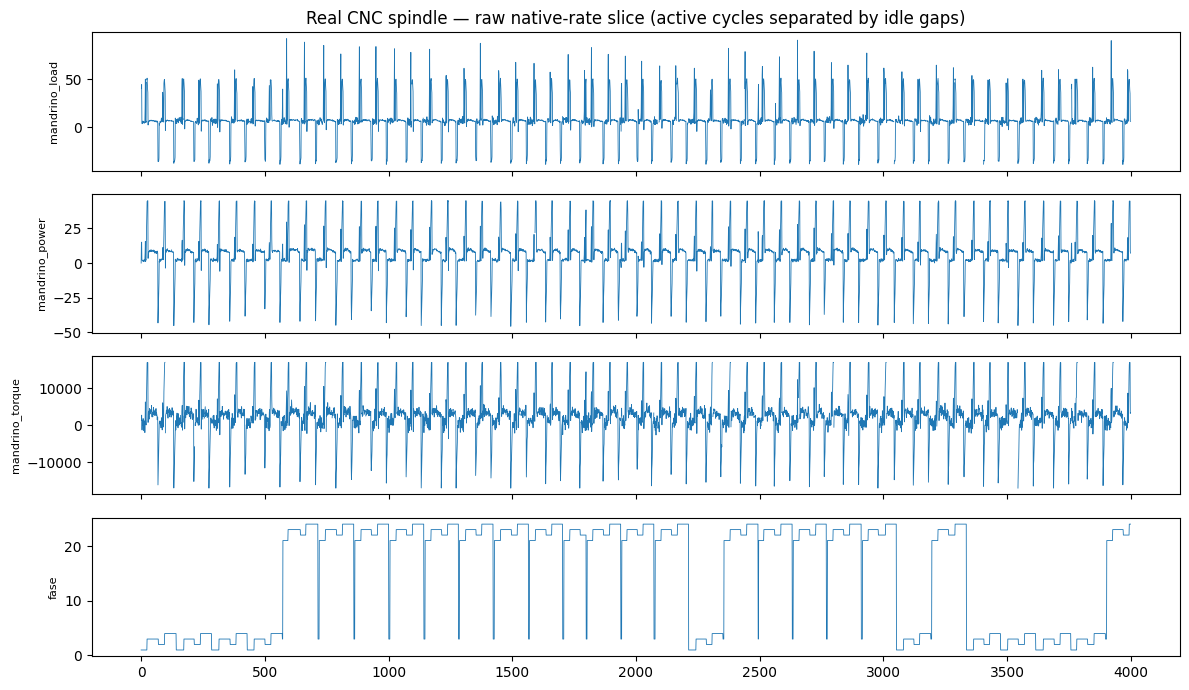

In [5]:
# Real wide stream (if available) — plot a slice showing the active/idle pattern.
if WIDE_PARQUET.exists() and HAVE_MPL:
    wide = pd.read_parquet(WIDE_PARQUET)
    sl = wide.iloc[:4000]
    fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
    for ax, col in zip(axes, ['mandrino_load', 'mandrino_power', 'mandrino_torque', 'fase']):
        ax.plot(sl[col].values, lw=0.6)
        ax.set_ylabel(col, fontsize=8)
    axes[0].set_title('Real CNC spindle — raw native-rate slice (active cycles separated by idle gaps)')
    plt.tight_layout(); plt.show()
else:
    print('wide parquet absent or matplotlib missing — skipping real-data plot')

## 3 — Replay the profile through the CNC engine

`simulator-local/cnc_engine.py` is the **single behavioural model** shared by
the live simulator and the offline trainer (train/serve consistency). We
generate a few hours of 1 Hz telemetry and confirm it reproduces the real
duty cycle and signal distributions.

In [6]:
from cnc_engine import CncEngine, generate_frame, load_profile

prof = load_profile(PROFILE_JSON)
vals, mask = generate_frame(prof, n_seconds=4 * 3600, seed=7)
print('generated   :', vals.shape, '@ 1 Hz')
print('duty cycle  : synthetic %.1f%%  vs real %.1f%%' % (100 * mask.mean(), 100 * prof['duty_cycle']))
act = vals[mask]
for i, s in enumerate(prof['sensors']):
    print(f"  {s:16s} active mean={act[:, i].mean():8.2f}  std={act[:, i].std():7.2f}  ({prof['units'][s]})")

generated   : (14400, 3) @ 1 Hz
duty cycle  : synthetic 41.7%  vs real 9.9%
  mandrino_load    active mean=    8.94  std=  14.12  (%)
  mandrino_power   active mean=    6.43  std=  11.70  (kW)
  mandrino_torque  active mean= 2442.53  std=4308.12  (N*cm)


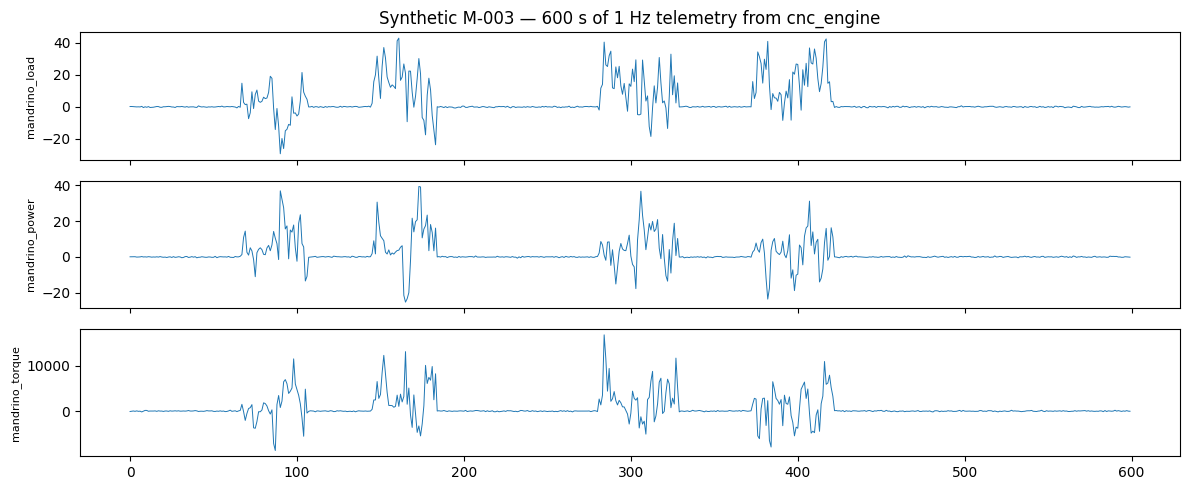

In [7]:
# Synthetic active-cycle slice — should look like a real machining cycle.
if HAVE_MPL:
    eng = CncEngine(prof, np.random.default_rng(1))
    rows, modes = [], []
    for _ in range(600):
        eng.step(1.0); s = eng.sample()
        rows.append([s[k] for k in prof['sensors']]); modes.append(eng.active)
    arr = np.array(rows)
    fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
    for ax, i, s in zip(axes, range(3), prof['sensors']):
        ax.plot(arr[:, i], lw=0.7); ax.set_ylabel(s, fontsize=8)
    axes[0].set_title('Synthetic M-003 — 600 s of 1 Hz telemetry from cnc_engine')
    plt.tight_layout(); plt.show()
else:
    print('matplotlib missing — skipping synthetic plot')

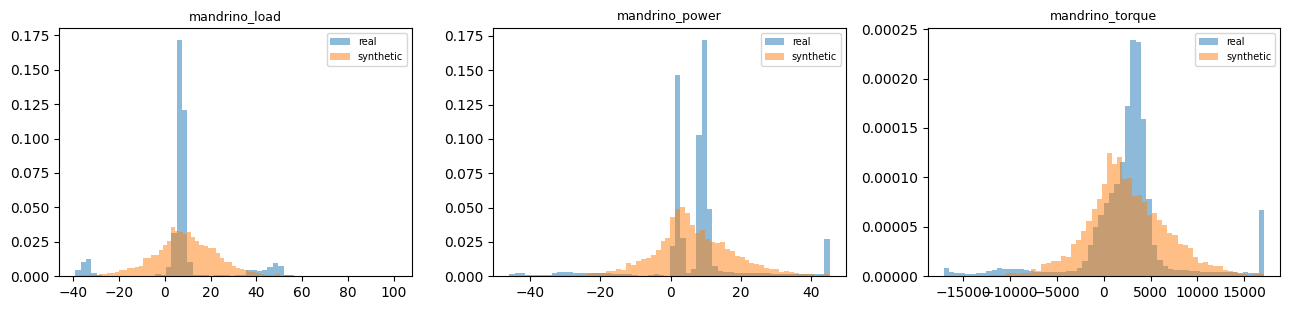

In [8]:
# Side-by-side active-cycle histograms: real vs synthetic.
if WIDE_PARQUET.exists() and HAVE_MPL:
    wide = pd.read_parquet(WIDE_PARQUET)
    real_active = wide[wide['fase'].fillna(0) > 0]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    for ax, i, s in zip(axes, range(3), prof['sensors']):
        ax.hist(real_active[s].dropna().values, bins=60, density=True, alpha=0.5, label='real')
        ax.hist(act[:, i], bins=60, density=True, alpha=0.5, label='synthetic')
        ax.set_title(s, fontsize=9); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()
else:
    print('wide parquet absent or matplotlib missing — skipping comparison')

## 4 — How M-003 plugs into the fleet

`simulator-local/simulate_machines.py` is heterogeneous: ids `1..n-1` are FSM
physics machines, and the **last id is the CNC engine** when a profile is
passed. The same is true in the cloud image (`simulator-cloud`), driven by the
`SIM_CNC_PROFILE` environment variable.

```bash
# Local: M-001/M-002 FSM + M-003 CNC, 60 s smoke test
python simulator-local/simulate_machines.py \
  --machines 3 --rate 1 --duration 60 \
  --cnc-profile data/cnc_profile_M-003.json
```

The M-003 anomaly model is trained from this exact engine via
[`tools/train_cnc_m003.py`](../tools/train_cnc_m003.py) and registered into the
Eventhouse `models` table like M-001 / M-002 — one ONNX model per machine,
scored by the generic `score_multivariate_onnx_batch` KQL function.

In [9]:
# Build the heterogeneous fleet and step it briefly (offline, no Event Hub).
import simulate_machines as sm

fleet = sm.build_machines(3, cnc_profile=prof)
for k, m in fleet.items():
    for _ in range(60):
        m.step(1.0)
    print(f"{k:6s} {type(m).__name__:11s} sensors={len(m.sensor_names)} active={m.is_active()} {m.status()}")

M-001  Machine     sensors=8 active=False state=OFF load=0.00 T_motor=22.0C
M-002  Machine     sensors=8 active=False state=OFF load=0.00 T_motor=22.0C
M-003  CNCMachine  sensors=3 active=False mode=idle
